In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.ndimage as ndi
import seaborn as sns
from matplotlib.patches import Rectangle
from nd2reader import ND2Reader
from skimage import exposure
from skimage.feature import peak_local_max
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import regionprops_table
from skimage.segmentation import watershed
from tqdm import tqdm

from rebinding.fig_utils import defaultStyle, save_fig
from rebinding.nd2_handling import visualize_nd2

defaultStyle(fs=14)

# Doxorubicin

In [73]:
# %matplotlib widget
# images = ND2Reader("../data/BYL284/BYL284_mtx_dox_test.nd2")
# visualize_nd2("../data/BYL284/BYL284_mtx_dox_test.nd2")
images = ND2Reader("../data/BYL284/BYL284_dox_mtx_test.nd2")
images.iter_axes = "vt"

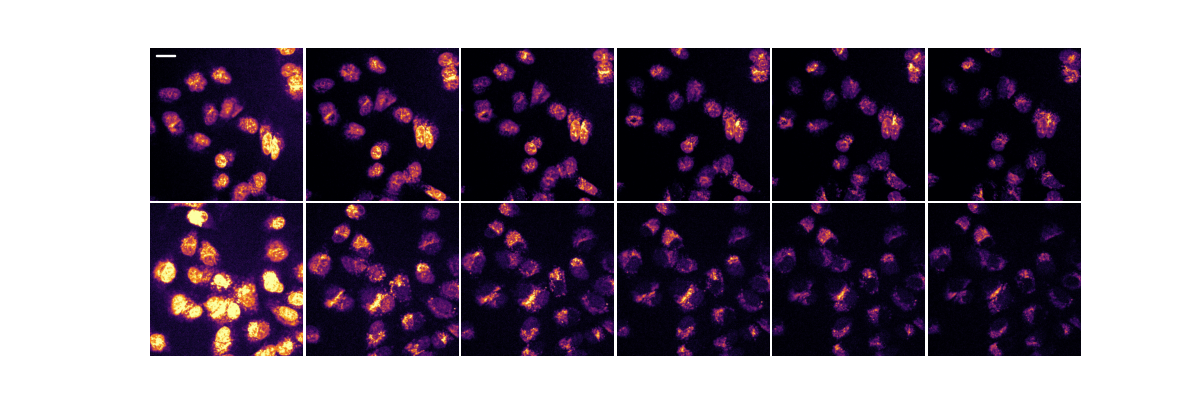

In [77]:
_, ax = plt.subplots(2, 6, figsize=(12, 4))
plt.subplots_adjust(wspace=0.02, hspace=0.01)
px_sz = 0.324760521060985
s0 = (570, 0)
s1 = (250, 630)
s = 500
for i, t in enumerate([0, 20, 40, 60, 80, 99]):
    im1 = images[t][s0[0] : s0[0] + s, s0[1] : s0[1] + s]
    im2 = images[t + 100][s1[0] : s1[0] + s, s1[1] : s1[1] + s]
    if i == 0:
        v1, v2 = np.percentile(im1, (25, 99))
    im1 = exposure.rescale_intensity(im1, in_range=(v1, v2))
    im2 = exposure.rescale_intensity(im2, in_range=(v1, v2))
    ax[0, i].imshow(im1, cmap="inferno")
    ax[1, i].imshow(im2, cmap="inferno")
scalebar = Rectangle((20, 20), 20 // px_sz, 5, color="w")
ax[0, 0].add_patch(scalebar)

for bx in ax.flatten():
    bx.axis("off")

# save_fig("fig3-doxorubicin", fmt="png", dpi=300, tight_layout=False)

In [78]:
def im_seg(im_raw, thresh):
    im = gaussian(im_raw, 3)
    lower_thresh = threshold_otsu(im) * thresh
    im_binary = im > lower_thresh  #  & (im < upper_thresh)
    distance = ndi.distance_transform_edt(im_binary)
    coords = peak_local_max(distance, footprint=np.ones((50, 50)), labels=im_binary)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=im_binary)
    return labels


im_raw = images[0]


def size_filter(labels, thresh, size_thresh):
    labels = im_seg(im_raw, thresh)
    areas = regionprops_table(labels, im_raw, properties=["area"])["area"]
    labels_filtered = labels.copy()
    labels_filtered[np.isin(labels, np.where(areas < size_thresh)[0] + 1)] = 0
    return labels_filtered


def calc_fl(im_raw, labels):
    return regionprops_table(labels, im_raw, properties=["intensity_mean"])[
        "intensity_mean"
    ]

# labels = size_filter(im_seg(im_raw), 1e3)
# _, ax = plt.subplots(1, 2, figsize=(7, 3))
# ax[0].imshow(im_raw)
# ax[1].imshow(labels, cmap="Set3")
# for bx in ax:
#     bx.axis("off")

In [79]:
results = []
for i in tqdm(range(200)):
    im_raw = images[i]
    labels = size_filter(im_raw, 0.9, 1e3)
    results.append(calc_fl(im_raw, labels))

# results = np.array(results)
time_arr = [[i % 100] * len(results[i]) for i in range(len(results))]
group_arr = [[i // 100] * len(results[i]) for i in range(len(results))]
results_merge = np.concatenate(results)
time_arr = np.concatenate(time_arr)
group_arr = np.concatenate(group_arr)
data = np.stack([time_arr, group_arr, results_merge], axis=1)

df = pd.DataFrame(data, columns=["Time (min)", "group", "Cell fluorescence"])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:49<00:00,  4.01it/s]


Saving figure fig3-doxorubicin-curve


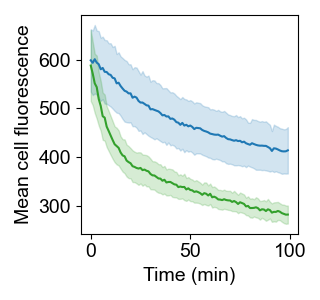

In [80]:
colors = plt.cm.Paired.colors
color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.2, 3))
ax.set_ylabel("Mean cell fluorescence")
ax.set_xlabel("Time (min)")
sns.lineplot(
    df[df.group == 0],
    x="Time (min)",
    y="Cell fluorescence",
    errorbar="sd",
    color=color1,
    legend=False,
)
sns.lineplot(
    df[df.group == 1],
    x="Time (min)",
    y="Cell fluorescence",
    errorbar="sd",
    color=color2,
    legend=False,
)

save_fig("fig3-doxorubicin-curve", fmt="png", dpi=300)

# Mitoxantrone

In [83]:
%matplotlib widget
images = ND2Reader("../data/BYL284/BYL284_mtx_dox_test.nd2")
print(images.shape)
# visualize_nd2("../data/BYL284/BYL284_mtx_dox_test.nd2")
# images = visualize_nd2("../data/BYL284/BYL284_dox_mtx_test.nd2")
images.iter_axes = "vt"

(179, 1140, 1570)


Saving figure FigEx6-mitoxantrone


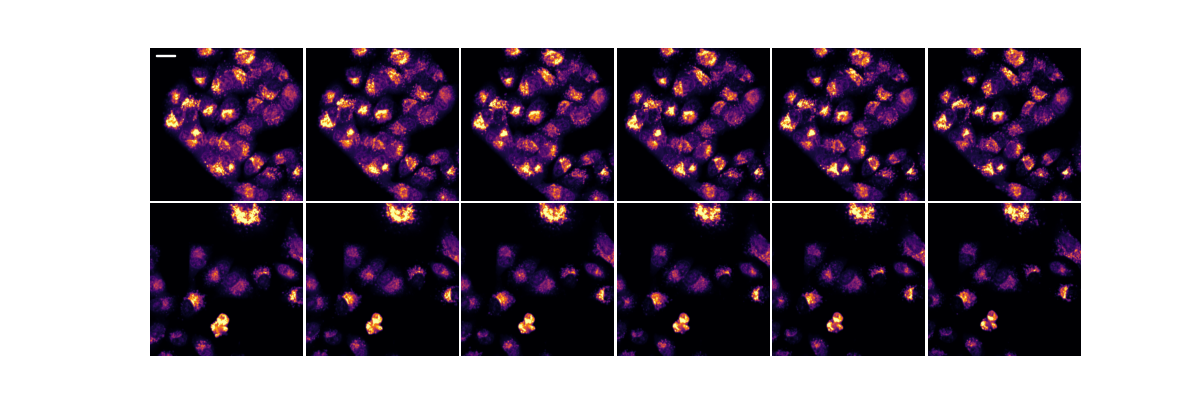

In [84]:
_, ax = plt.subplots(2, 6, figsize=(12, 4))
plt.subplots_adjust(wspace=0.02, hspace=0.01)
px_sz = 0.324760521060985
s0 = (600, 0)
s1 = (0, 1000)
s = 500
for i, t in enumerate([0, 5, 10, 15, 20, 30]):
    im2 = images[t][s0[0] : s0[0] + s, s0[1] : s0[1] + s]
    im1 = images[t + nTimes][s1[0] : s1[0] + s, s1[1] : s1[1] + s]
    if i == 0:
        v1, v2 = np.percentile(im2, (50, 99))
    im1 = exposure.rescale_intensity(im1, in_range=(v1, v2))
    im2 = exposure.rescale_intensity(im2, in_range=(v1, v2))
    ax[0, i].imshow(im1, cmap="inferno")
    ax[1, i].imshow(im2, cmap="inferno")
scalebar = Rectangle((20, 20), 20 // px_sz, 5, color="w")
ax[0, 0].add_patch(scalebar)

for bx in ax.flatten():
    bx.axis("off")

save_fig("FigEx6-mitoxantrone", fmt="png", dpi=300, tight_layout=False)

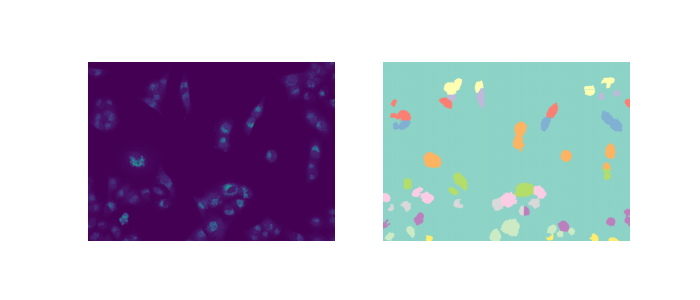

In [91]:
im_raw = images[0]
labels = size_filter(im_raw, 0.6, 1e3)
_, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(im_raw)
ax[1].imshow(labels, cmap="Set3")
for bx in ax:
    bx.axis("off")

In [92]:
results = []
nTimes = 179
for i in tqdm(range(2 * nTimes)):
    im_raw = images[i]
    labels = size_filter(im_raw, 0.6, 1e3)
    results.append(calc_fl(im_raw, labels))

# results = np.array(results)
time_arr = [[i % nTimes] * len(results[i]) for i in range(len(results))]
group_arr = [[i // nTimes] * len(results[i]) for i in range(len(results))]
results_merge = np.concatenate(results)
time_arr = np.concatenate(time_arr)
group_arr = np.concatenate(group_arr)
data = np.stack([time_arr, group_arr, results_merge], axis=1)

df = pd.DataFrame(data, columns=["Time (min)", "group", "Cell fluorescence"])
df = df[df["Time (min)"] < 100]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 358/358 [01:19<00:00,  4.48it/s]


Saving figure fig3-mitoxantrone-curve


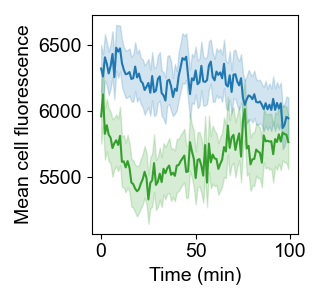

In [93]:
colors = plt.cm.Paired.colors
color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.2, 3))
ax.set_ylabel("Mean cell fluorescence")
ax.set_xlabel("Time (min)")
sns.lineplot(
    df[df.group == 1],
    x="Time (min)",
    y="Cell fluorescence",
    errorbar="se",
    color=color1,
    legend=False,
)
sns.lineplot(
    df[df.group == 0],
    x="Time (min)",
    y="Cell fluorescence",
    errorbar="se",
    color=color2,
    legend=False,
)

save_fig("fig3-mitoxantrone-curve", fmt="png", dpi=300)